In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram


def simulate_velocity(
    duration=300,
    fs=10,
    freq=0.05,
    amplitude=1.0,
    offset=0.0,
):
    """
    Physical velocity oscillates as a cosine.
    """
    t = np.arange(0, duration, 1/fs)

    velocity = (
        offset
        + amplitude * np.cos(2 * np.pi * freq * t)
    )

    return t, velocity


def velocity_to_bfi(
    velocity,
    midpoint=-2.0,
    slope=3.0,
    bfi_min=0.0,
    bfi_max=1.0,
):
    """
    Nonlinear sigmoid measurement model.

    BFI = sigmoid(velocity)
    """

    sigmoid = 1 / (1 + np.exp(-slope * (velocity - midpoint)))

    bfi = bfi_min + (bfi_max - bfi_min) * sigmoid

    return bfi


def compute_periodogram(signal, fs):
    f, pxx = periodogram(
        signal,
        fs=fs,
        detrend="constant",
        scaling="density"
    )

    return f, pxx


def plot_simulation_overlay(
    duration=300,
    fs=10,
    freq=0.05,
    amplitude=1.0,
    offset=0.0,
    sigmoid_slope=3.0,
):
    t, velocity = simulate_velocity(
        duration=duration,
        fs=fs,
        freq=freq,
        amplitude=amplitude,
        offset=offset,
    )

    bfi = velocity_to_bfi(
        velocity,
        slope=sigmoid_slope
    )

    f_vel, p_vel = compute_periodogram(velocity, fs)
    f_bfi, p_bfi = compute_periodogram(bfi, fs)

    # normalize for shape comparison
    vel_norm = (velocity - velocity.mean()) / velocity.std()
    bfi_norm = (bfi - bfi.mean()) / bfi.std()

    p_vel_norm = p_vel # / p_vel.max()
    p_bfi_norm = p_bfi # / p_bfi.max()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 8)
    )

    # Waveforms
    axes[0].plot(
        t, vel_norm,
        label="Velocity",
        lw=2
    )

    axes[0].plot(
        t, bfi_norm,
        label="BFI",
        lw=2,
        alpha=0.8
    )

    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Normalized signal")
    axes[0].set_title("Waveforms")
    axes[0].legend()

    # Periodograms
    axes[1].plot(
        f_vel,
        p_vel_norm,
        label="Velocity",
        lw=2
    )

    axes[1].plot(
        f_bfi,
        p_bfi_norm,
        label="BFI",
        lw=2,
        alpha=0.8
    )

    # axes[1].set_xlim(0, 0.5)
    axes[1].set_yscale('log')
    axes[1].set_xscale('log')

    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Normalized power")
    axes[1].set_title("Periodograms")
    axes[1].legend()

    plt.tight_layout()

    return {
        "t": t,
        "velocity": velocity,
        "bfi": bfi,
        "freq": f_vel,
        "power_velocity": p_vel,
        "power_bfi": p_bfi,
    }

{'t': array([0.000e+00, 1.000e-01, 2.000e-01, ..., 2.997e+02, 2.998e+02,
        2.999e+02]),
 'velocity': array([1.        , 0.99950656, 0.99802673, ..., 0.99556196, 0.99802673,
        0.99950656]),
 'bfi': array([0.99987661, 0.99987642, 0.99987587, ..., 0.99987495, 0.99987587,
        0.99987642]),
 'freq': array([0.00000000e+00, 3.33333333e-03, 6.66666667e-03, ...,
        4.99333333e+00, 4.99666667e+00, 5.00000000e+00]),
 'power_velocity': array([3.12820697e-35, 5.78495692e-32, 3.33529619e-31, ...,
        7.04828971e-32, 1.75101629e-32, 7.45585736e-33]),
 'power_bfi': array([4.73011368e-30, 1.15319690e-33, 6.19297616e-35, ...,
        7.99230136e-34, 8.76839729e-35, 4.82611622e-33])}

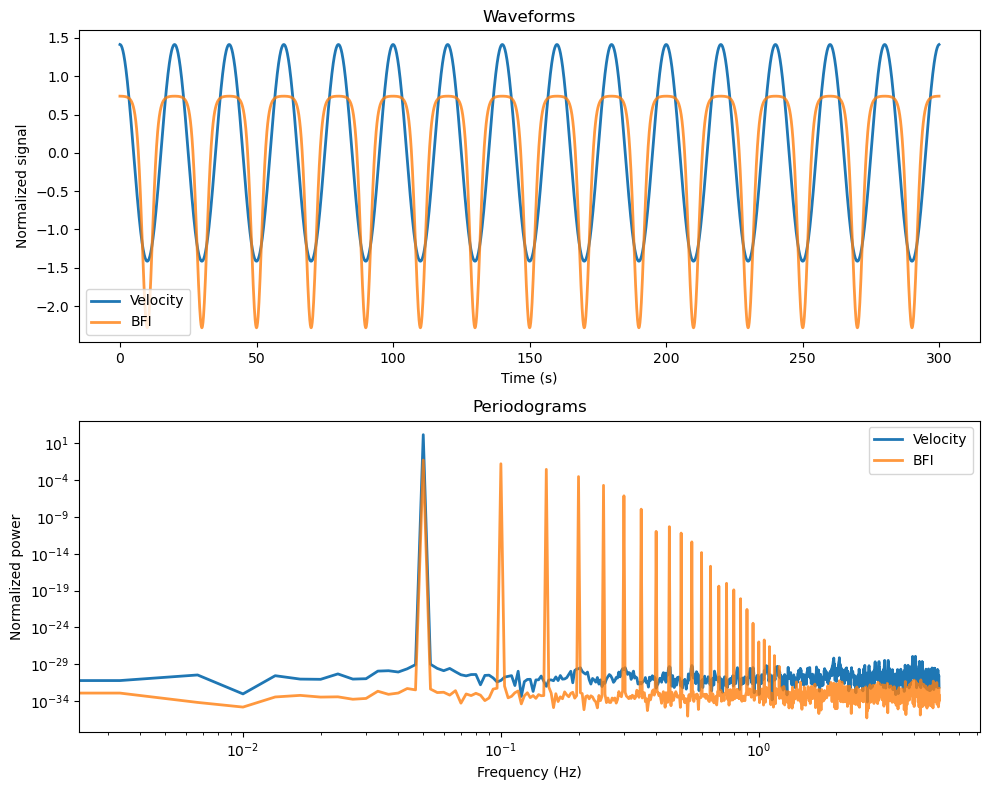

In [41]:
plot_simulation_overlay()